In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data = pd.read_csv('winequality-white.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


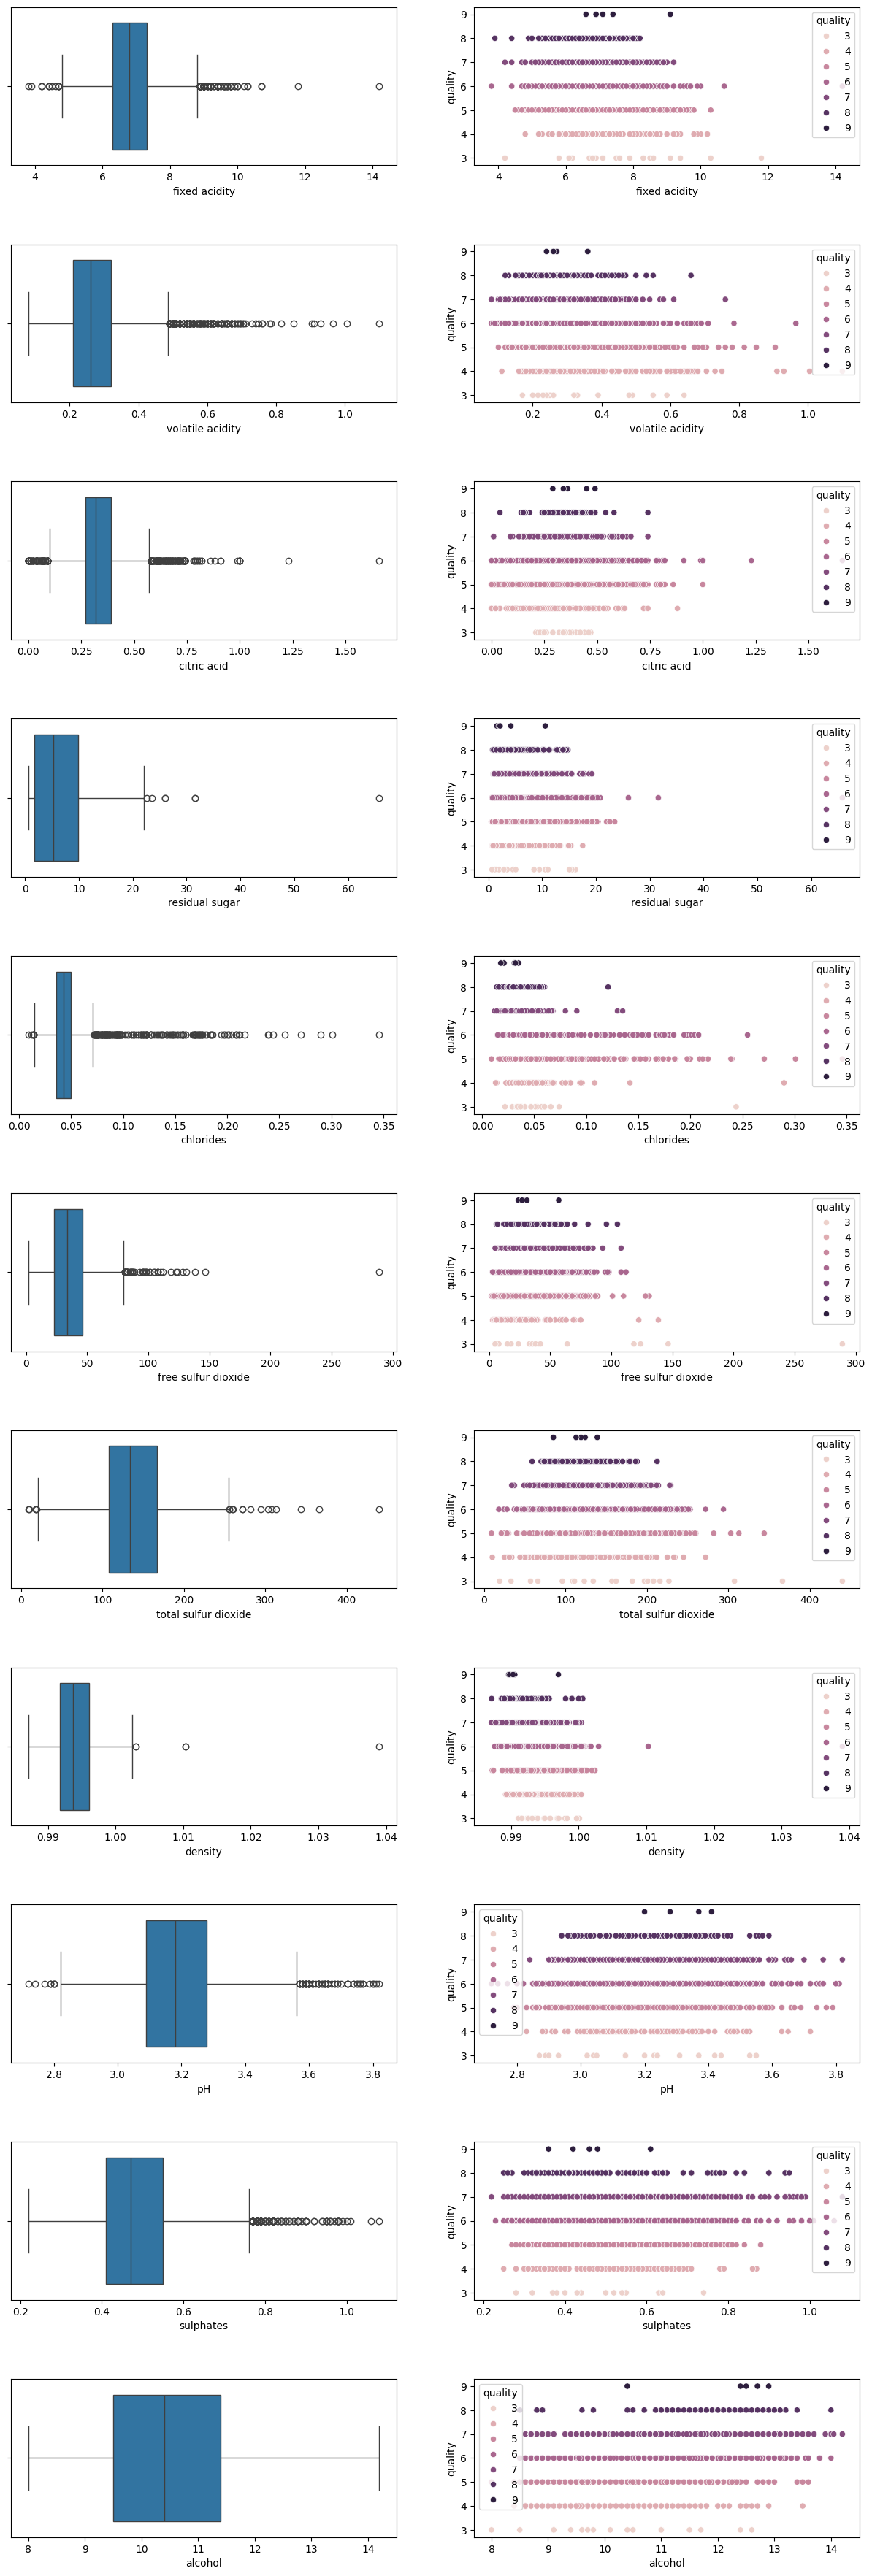

In [5]:
columns = list(data.columns)
fig, ax = plt.subplots(11, 2, figsize=(15, 45))
plt.subplots_adjust(hspace = 0.5)
for i in range(11) :
    # AX 1
    sns.boxplot(x=columns[i], data=data, ax=ax[i, 0])
    # Ax 2
    sns.scatterplot(x=columns[i], y='quality', data=data, hue='quality', ax=ax[i, 1])

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

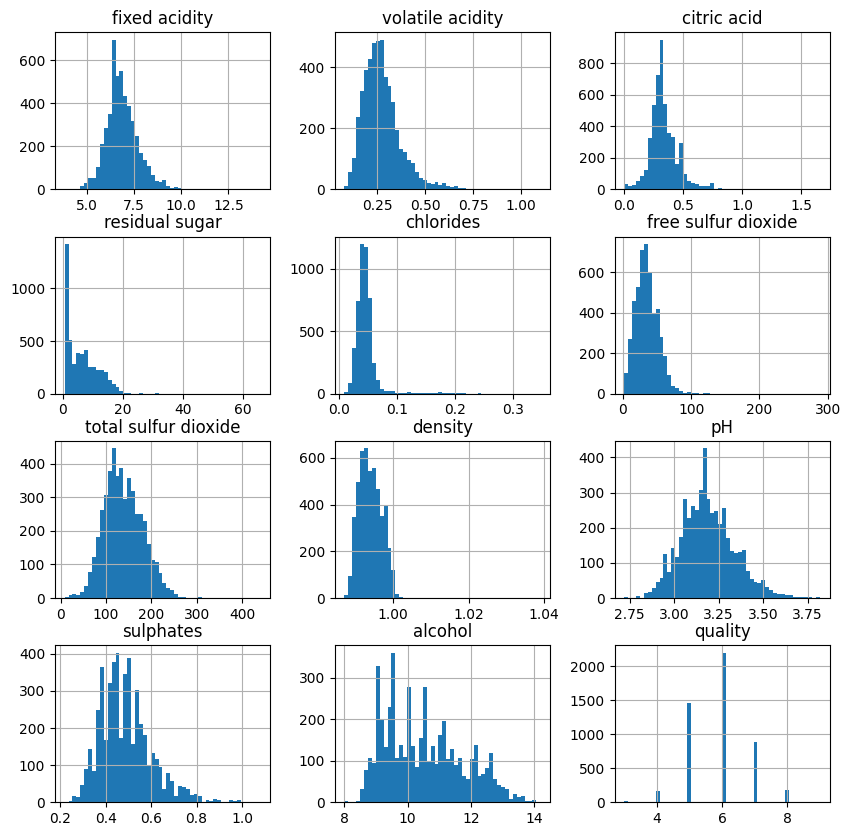

In [6]:
data.hist(figsize=(10, 10), bins=50)

In [7]:
features = data.drop(['quality'], axis=1)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print("Features",features.columns)

Features Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


In [8]:
kmeans = KMeans(n_clusters=5)
kmeans_pred = kmeans.fit_predict(features_scaled)

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


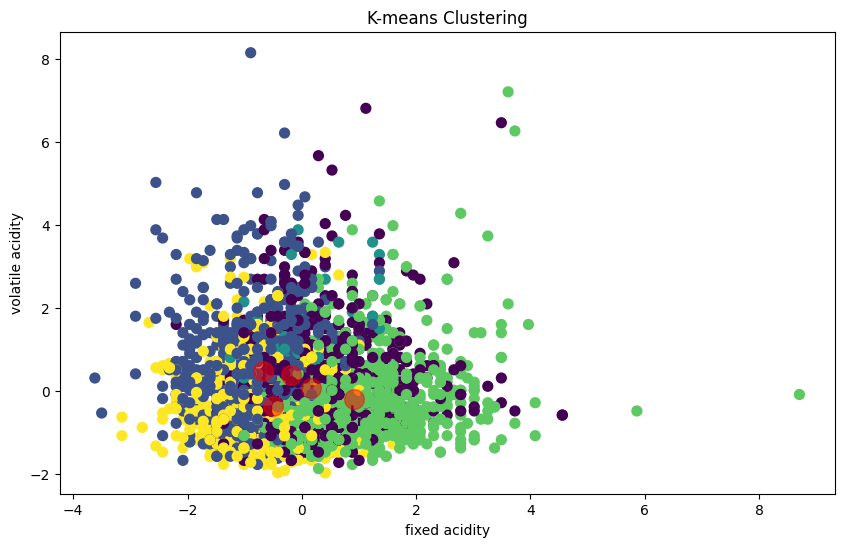

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=kmeans_pred, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.title('K-means Clustering')
plt.xlabel('fixed acidity')
plt.ylabel('volatile acidity')
plt.show()


In [10]:
hac = AgglomerativeClustering(n_clusters=4)
hac_pred = hac.fit_predict(features_scaled)


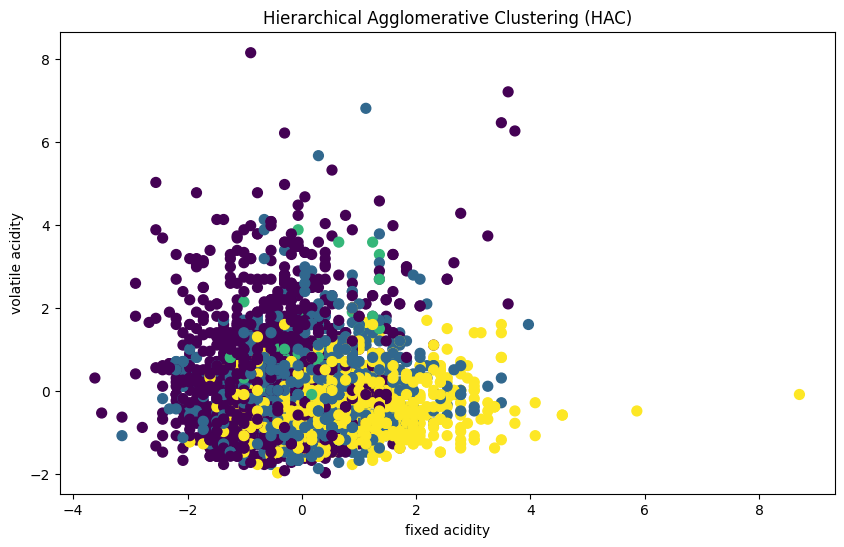

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=hac_pred, s=50, cmap='viridis')
plt.title('Hierarchical Agglomerative Clustering (HAC)')
plt.xlabel('fixed acidity')
plt.ylabel('volatile acidity')
plt.show()


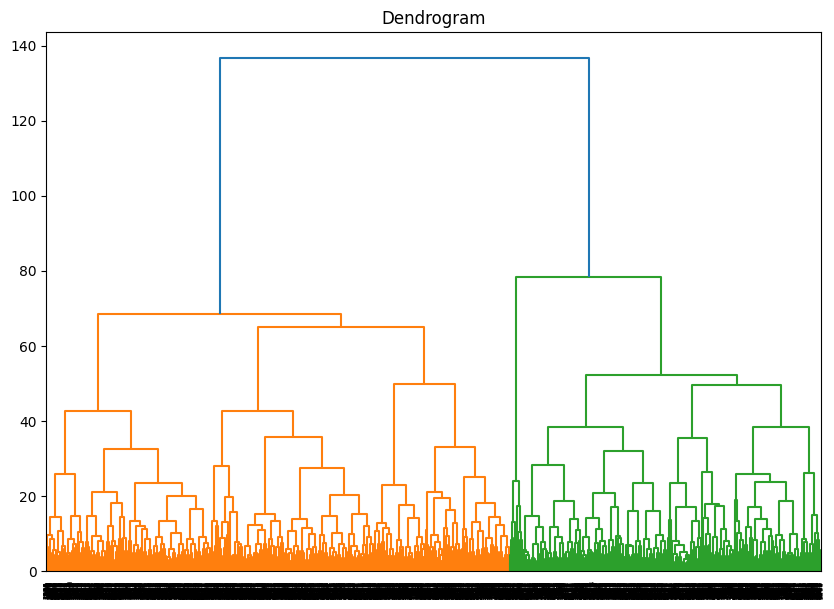

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(features_scaled, method='ward') 

plt.figure(figsize=(10, 7))
plt.title("Dendrogram")
dendrogram(Z)

plt.axhline(y=500, color='r', linestyle='--')  
plt.show()


In [13]:
dbscan = DBSCAN(eps=3, min_samples=5)
dbscan_pred = dbscan.fit_predict(features_scaled)


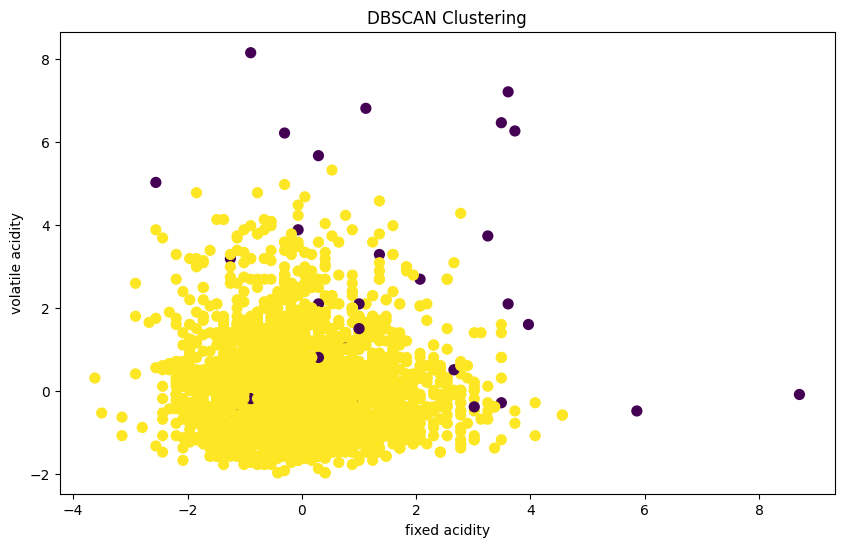

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=dbscan_pred, s=50, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('fixed acidity')
plt.ylabel('volatile acidity')
plt.show()


C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


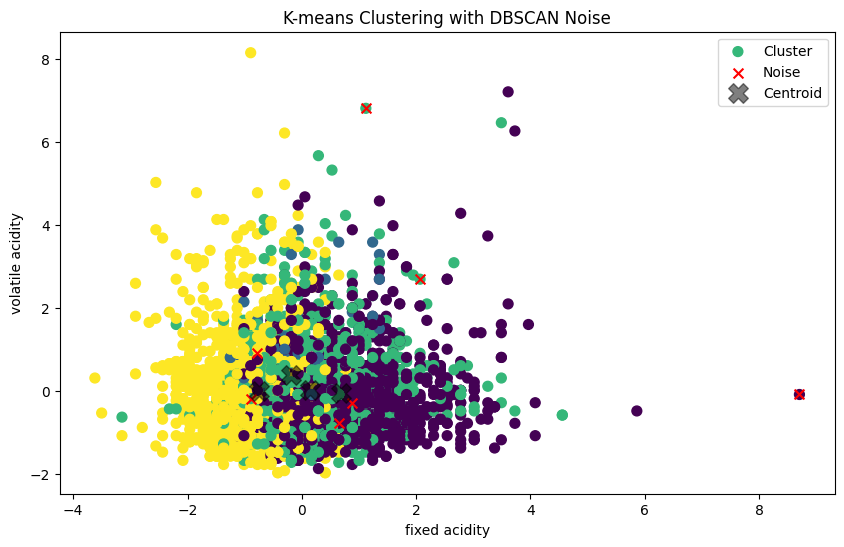

In [15]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

kmeans = KMeans(n_clusters=4)
kmeans_pred = kmeans.fit_predict(features_scaled)

dbscan = DBSCAN(eps=4, min_samples=5)
dbscan_pred = dbscan.fit_predict(features_scaled)

plt.figure(figsize=(10, 6))

plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=kmeans_pred, s=50, cmap='viridis', label='Cluster')

noise = features_scaled[dbscan_pred == -1]
plt.scatter(noise[:, 0], noise[:, 1], c='red', s=50, marker='x', label='Noise')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, marker='X', label='Centroid')

plt.title('K-means Clustering with DBSCAN Noise')
plt.xlabel('fixed acidity')
plt.ylabel('volatile acidity')
plt.legend()
plt.show()


In [16]:
mean_shift = MeanShift(bandwidth=5)  
mean_shift_pred = mean_shift.fit_predict(features_scaled)


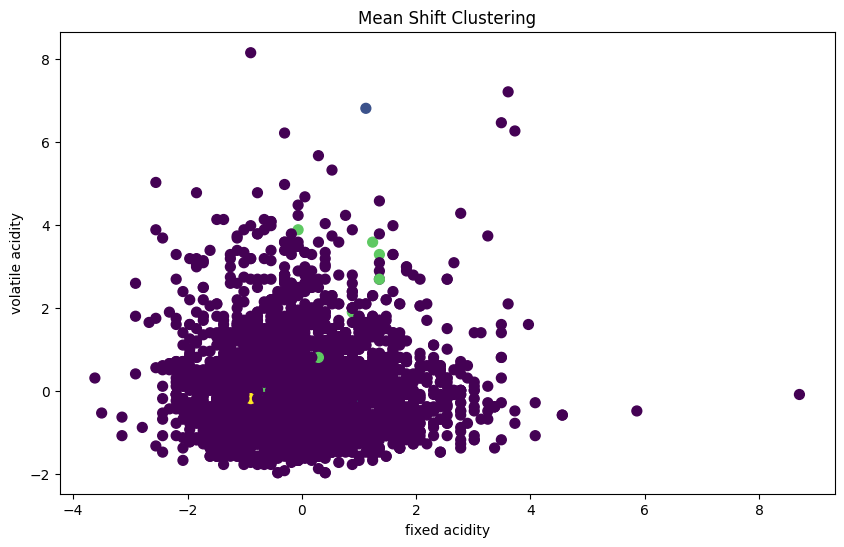

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=mean_shift_pred, s=50, cmap='viridis')
plt.title('Mean Shift Clustering')
plt.xlabel('fixed acidity')
plt.ylabel('volatile acidity')
plt.show()


Mean Shift demonstrated the highest Silhouette score of 0.328. This indicates that Mean Shift managed to identify well-separated clusters and assign points to clusters in a way that aligns with their underlying distribution. It suggests that the clusters have little overlap and points within a cluster are close to each other.

KMeans with a score of 0.189 and HAC (Hierarchical Agglomerative Clustering) with 0.158 both exhibit positive but modest Silhouette scores. These values imply that while there is some cluster structure found by these methods, the separation between different clusters is not as distinct. Clusters may be closer together or less dense, leading to a lower score compared to Mean Shift.

DBSCAN received a negative Silhouette score of -0.251, indicating a poor clustering structure. With negative values, it's possible that many points do not belong clearly to a cluster, or there's substantial overlap between clusters. This could be due to DBSCAN's parameters not being well-tuned for this particular dataset, or perhaps the dataset's structure is not well-suited to density-based clustering.

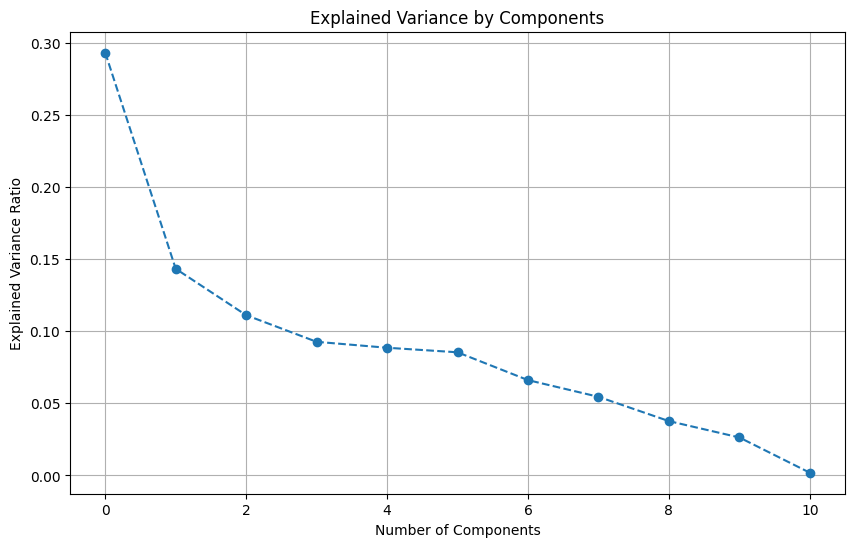

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Separating out the features and the target variable
X = data.drop('quality', axis=1)  # Features
y = data['quality']  # Target variable

# Standardizing the features
X_scaled = StandardScaler().fit_transform(X)

# Performing PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plotting the Explained Variance Ratio
plt.figure(figsize=(10, 6))
plt.plot(pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()


In [19]:
# Transforming data using PCA with a selected number of components
# Let's say we decide to keep 3 components based on the plot

pca_illustrative = PCA(n_components=3)
X_pca_illustrative = pca_illustrative.fit_transform(X_scaled)

# X_pca_selected now contains the transformed data with 3 principal components

# Convert the PCA-transformed data back into a DataFrame for better visualization
pca_columns = [f'PC{i+1}' for i in range(X_pca_illustrative.shape[1])]
df_pca = pd.DataFrame(data=X_pca_illustrative, columns=pca_columns)

# Display the first few rows of the PCA-transformed DataFrame
df_pca.head()

,PC1,PC2,PC3
0,3.676944,-0.545233,-0.930422
1,-0.644588,0.430770,-0.356331
2,0.155291,-1.189800,-0.017532
3,1.455374,0.099680,-0.001956
4,1.455374,0.099680,-0.001956


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

models = {
    "KNeighborsClassifier": KNeighborsClassifier(),
    "SVC": SVC(),
    "RandomForestClassifier": RandomForestClassifier(),
    "ExtraTreesClassifier": ExtraTreesClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "GradientBoostingClassifier": GradientBoostingClassifier()
}

classification_reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    classification_reports[name] = classification_report(y_test, y_pred)

accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)

for name, accuracy in accuracy_scores.items():
    print(f"{name}: {accuracy}")

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: Unde

KNeighborsClassifier: 0.5489795918367347
SVC: 0.560204081632653
RandomForestClassifier: 0.6908163265306122
ExtraTreesClassifier: 0.6948979591836735
DecisionTreeClassifier: 0.6030612244897959
GradientBoostingClassifier: 0.5704081632653061


Data dimensionality reduction using PCA not only reduces data complexity but also improves the ability to distinguish between clusters, as demonstrated by higher Silhouette scores after dimensionality reduction.

PCA can remove "noise" from data and focus on the most important information, which makes k-means more effective at distinguishing clusters.

Different clustering techniques can be suitable for different types of data structures. In this case, Mean Shift and k-means after PCA show good performance, while DBSCAN is not suitable for this particular data structure.